# Deep Learning for Perception - Assignment 01
### Building, Breaking and Fixing a Neural Network
**Dataset:** Fashion-MNIST &nbsp;|&nbsp; **Platform:** Kaggle, GPU T4 x2 &nbsp;|&nbsp;


# Imports and Configuration

In [1]:
import os, time, math, random, itertools
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, mean_squared_error, mean_absolute_error)

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.precision", 4)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0), "| GPU count:", torch.cuda.device_count())


Using device: cuda
GPU: Tesla T4 | GPU count: 2


# Random Seed

In [2]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed set to {SEED} for python.random, numpy, and torch (CPU + all GPUs).")


Random seed set to 42 for python.random, numpy, and torch (CPU + all GPUs).


# Dataset Loading and Preprocessing



In [3]:
import glob

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def _find_fashion_mnist_csvs(search_root="/kaggle/input"):
    """Kaggle mounts a dataset under /kaggle/input/<slug>/..., and the exact <slug> folder
    name depends on how the dataset was added (it is not always "fashionmnist"), and some
    versions nest the CSVs one directory deeper. Rather than hard-code a path, search for the
    two files by name anywhere under /kaggle/input so this cell does not need editing."""
    train_candidates = glob.glob(os.path.join(search_root, "**", "fashion-mnist_train.csv"),
                                  recursive=True)
    test_candidates = glob.glob(os.path.join(search_root, "**", "fashion-mnist_test.csv"),
                                 recursive=True)
    if train_candidates and test_candidates:
        return train_candidates[0], test_candidates[0]
    return None, None


def load_fashion_mnist(data_dir=None):
    if data_dir is not None:
        train_path = os.path.join(data_dir, "fashion-mnist_train.csv")
        test_path = os.path.join(data_dir, "fashion-mnist_test.csv")
    else:
        train_path, test_path = _find_fashion_mnist_csvs()

    if train_path is None or not os.path.exists(train_path):
        print("Could not auto-locate fashion-mnist_train.csv / fashion-mnist_test.csv.")
        print("Contents of /kaggle/input:")
        for root, dirs, files in os.walk("/kaggle/input"):
            for f in files:
                print(" ", os.path.join(root, f))
        raise FileNotFoundError(
            "Add the dataset via Kaggle's 'Add Input' -> search 'Fashion MNIST' -> "
            "zalando-research/fashionmnist, then re-run this cell. If it is already added but "
            "still not found, copy the exact path printed above into DATA_DIR below and re-run."
        )

    print(f"Loading train CSV from: {train_path}")
    print(f"Loading test  CSV from: {test_path}")
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    y_train_full = train_df["label"].to_numpy()
    X_train_full = train_df.drop(columns=["label"]).to_numpy(dtype=np.float32)
    y_test = test_df["label"].to_numpy()
    X_test = test_df.drop(columns=["label"]).to_numpy(dtype=np.float32)

    X_train_full /= 255.0
    X_test /= 255.0
    return X_train_full, y_train_full, X_test, y_test

X_train_full, y_train_full, X_test, y_test = load_fashion_mnist()
print("Full training pool:", X_train_full.shape, y_train_full.shape)
print("Held-out test set :", X_test.shape, y_test.shape)
print("Pixel range after normalisation -> min:", X_train_full.min(), "max:", X_train_full.max())

Loading train CSV from: /kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
Loading test  CSV from: /kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
Full training pool: (60000, 784) (60000,)
Held-out test set : (10000, 784) (10000,)
Pixel range after normalisation -> min: 0.0 max: 1.0


# Train/Validation/Test Split

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20, random_state=SEED, stratify=y_train_full
)

print(f"Train samples     : {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples      : {X_test.shape[0]}  (untouched until Part 7)")

def class_distribution(y, name):
    vals, counts = np.unique(y, return_counts=True)
    dist = pd.Series(counts, index=[CLASS_NAMES[v] for v in vals], name=name)
    return dist

dist_table = pd.concat([
    class_distribution(y_train, "Train"),
    class_distribution(y_val, "Validation"),
    class_distribution(y_test, "Test"),
], axis=1)
dist_table.loc["TOTAL"] = dist_table.sum()
dist_table


Train samples     : 48000
Validation samples: 12000
Test samples      : 10000  (untouched until Part 7)


,Train,Validation,Test
T-shirt/top,4800,1200,1000
Trouser,4800,1200,1000
Pullover,4800,1200,1000
Dress,4800,1200,1000
Coat,4800,1200,1000
Sandal,4800,1200,1000
Shirt,4800,1200,1000
Sneaker,4800,1200,1000
Bag,4800,1200,1000
Ankle boot,4800,1200,1000


# Exploratory Data Information

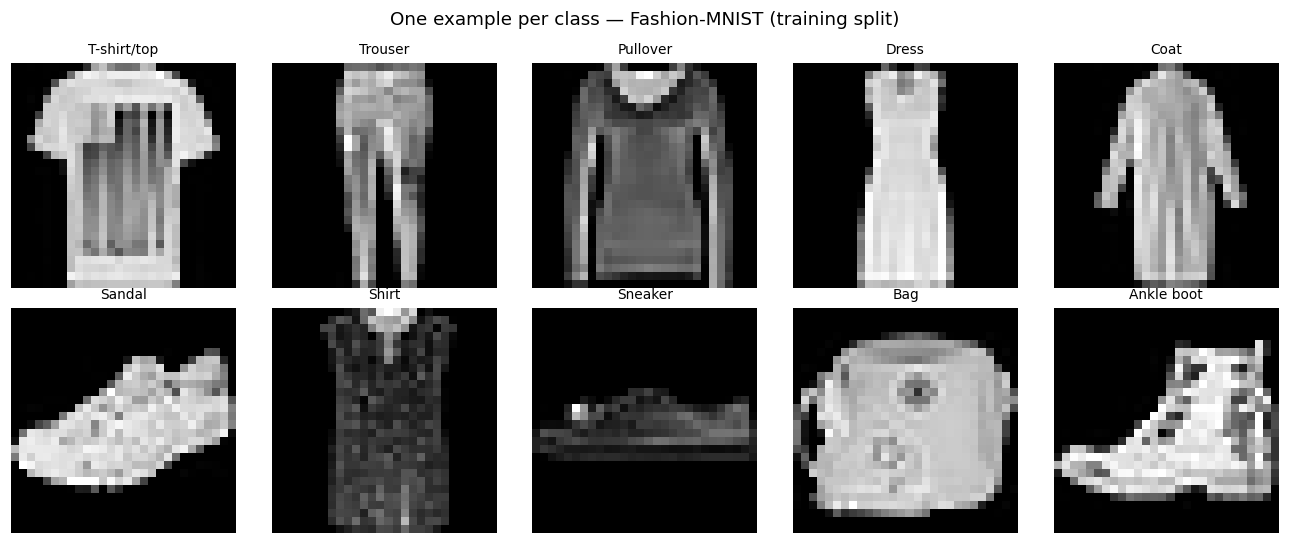

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng_display = np.random.default_rng(SEED)
for cls in range(10):
    idx = rng_display.choice(np.where(y_train == cls)[0])
    ax = axes[cls // 5, cls % 5]
    ax.imshow(X_train[idx].reshape(28, 28), cmap="gray")
    ax.set_title(CLASS_NAMES[cls], fontsize=9)
    ax.axis("off")
fig.suptitle("One example per class — Fashion-MNIST (training split)")
plt.tight_layout()
plt.savefig("fig_eda_examples.png", dpi=150)
plt.show()


In [6]:
class ArrayDataset(Dataset):
    """Wraps numpy X, y arrays as a torch Dataset."""
    def __init__(self, X, y=None, transform=None):
        self.X = X.astype(np.float32)
        self.y = None if y is None else y.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform is not None:
            x = self.transform(x)
        x = torch.from_numpy(x.copy())
        if self.y is None:
            return x
        return x, torch.tensor(self.y[idx])


def make_loaders(X_tr, y_tr, X_va, y_va, batch_size=128, transform=None, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    train_ds = ArrayDataset(X_tr, y_tr, transform=transform)
    val_ds = ArrayDataset(X_va, y_va)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
    val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)
    return train_loader, val_loader


def evaluate(model, loader, criterion, device=DEVICE, targets_are_onehot=False, n_classes=10):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            if targets_are_onehot:
                yb_oh = F.one_hot(yb, n_classes).float()
                loss = criterion(out, yb_oh)
            else:
                loss = criterion(out, yb)
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            n += xb.size(0)
    return total_loss / n, correct / n


def train_model(model, train_loader, val_loader, optimizer, criterion, epochs,
                 device=DEVICE, targets_are_onehot=False, n_classes=10, verbose=True,
                 track_first_layer_grad=False, first_layer_param_name=None):
    """Generic training loop reused by Parts 2-6. Returns a history dict."""
    model.to(device)
    history = defaultdict(list)
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, n = 0.0, 0, 0
        grad_abs_sum, grad_abs_count = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            if targets_are_onehot:
                yb_oh = F.one_hot(yb, n_classes).float()
                loss = criterion(out, yb_oh)
            else:
                loss = criterion(out, yb)
            loss.backward()

            if track_first_layer_grad and first_layer_param_name is not None:
                g = dict(model.named_parameters())[first_layer_param_name].grad
                if g is not None:
                    grad_abs_sum += g.abs().mean().item()
                    grad_abs_count += 1

            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            n += xb.size(0)

        train_loss, train_acc = running_loss / n, correct / n
        val_loss, val_acc = evaluate(model, val_loader, criterion, device,
                                      targets_are_onehot, n_classes)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if track_first_layer_grad and grad_abs_count > 0:
            history["first_layer_mean_abs_grad"].append(grad_abs_sum / grad_abs_count)
        if verbose:
            print(f"  epoch {epoch:3d}/{epochs} | train_loss={train_loss:.4f} "
                  f"train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    return dict(history)


def epochs_to_reach(history_val_acc, threshold=0.85):
    for i, acc in enumerate(history_val_acc, start=1):
        if acc >= threshold:
            return i
    return None  


def plot_curves(curves, xlabel, ylabel, title, legend_labels=None, savepath=None):
    plt.figure(figsize=(7, 5))
    for i, y in enumerate(curves):
        label = legend_labels[i] if legend_labels else None
        plt.plot(range(1, len(y) + 1), y, label=label, marker="o", markersize=3)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.title(title)
    if legend_labels:
        plt.legend()
    plt.grid(alpha=0.3)
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()

print("Helper functions defined: ArrayDataset, make_loaders, evaluate, train_model, "
      "epochs_to_reach, plot_curves")


Helper functions defined: ArrayDataset, make_loaders, evaluate, train_model, epochs_to_reach, plot_curves


# Part 1 — NumPy Backpropagation



## Forward Pass

In [7]:
class MLPNumpy:
    """784 -> 64 (ReLU) -> 10 (Softmax), trained with categorical cross-entropy."""

    def __init__(self, n_in=784, n_hidden=64, n_out=10, seed=SEED):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2.0 / n_in), size=(n_in, n_hidden)).astype(np.float64)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.normal(0, np.sqrt(1.0 / n_hidden), size=(n_hidden, n_out)).astype(np.float64)
        self.b2 = np.zeros((1, n_out))

    def get_params(self):
        return {"W1": self.W1, "b1": self.b1, "W2": self.W2, "b2": self.b2}

    @staticmethod
    def relu(z):
        return np.maximum(0, z)

    @staticmethod
    def relu_grad(z):
        return (z > 0).astype(z.dtype)

    @staticmethod
    def softmax(z):
        z = z - np.max(z, axis=1, keepdims=True)    
        e = np.exp(z)
        return e / np.sum(e, axis=1, keepdims=True)

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = self.relu(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = self.softmax(z2)
        cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "a2": a2}
        return a2, cache

    @staticmethod
    def cce_loss(probs, y_onehot):
        eps = 1e-12
        return -np.sum(y_onehot * np.log(probs + eps)) / probs.shape[0]


## Backward Pass

In [8]:
def _mlp_backward(self, cache, y_onehot):
    n = cache["X"].shape[0]
    dz2 = (cache["a2"] - y_onehot) / n                 
    dW2 = cache["a1"].T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)
    da1 = dz2 @ self.W2.T
    dz1 = da1 * self.relu_grad(cache["z1"])
    dW1 = cache["X"].T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

def _mlp_step(self, grads, lr):
    self.W1 -= lr * grads["W1"]
    self.b1 -= lr * grads["b1"]
    self.W2 -= lr * grads["W2"]
    self.b2 -= lr * grads["b2"]

MLPNumpy.backward = _mlp_backward
MLPNumpy.step = _mlp_step
print("MLPNumpy.backward and MLPNumpy.step attached.")


MLPNumpy.backward and MLPNumpy.step attached.


## Training

In [9]:
set_seed(SEED)

N_SUBSET = 5000
EPOCHS_NUMPY = 20
LR_NUMPY = 0.5

idx_subset = np.random.default_rng(SEED).choice(len(X_train), size=N_SUBSET, replace=False)
X_sub = X_train[idx_subset].astype(np.float64)
y_sub = y_train[idx_subset]
y_sub_onehot = np.eye(10)[y_sub]

model_np = MLPNumpy(784, 64, 10, seed=SEED)
loss_history_np = []
for epoch in range(1, EPOCHS_NUMPY + 1):
    probs, cache = model_np.forward(X_sub)
    loss = model_np.cce_loss(probs, y_sub_onehot)
    grads = model_np.backward(cache, y_sub_onehot)
    model_np.step(grads, lr=LR_NUMPY)
    train_acc = (probs.argmax(1) == y_sub).mean()
    loss_history_np.append(loss)
    print(f"epoch {epoch:2d}/{EPOCHS_NUMPY} | loss={loss:.4f} | train_acc={train_acc:.4f}")


epoch  1/20 | loss=2.3184 | train_acc=0.1798
epoch  2/20 | loss=2.0344 | train_acc=0.1982
epoch  3/20 | loss=2.2567 | train_acc=0.2114
epoch  4/20 | loss=2.6720 | train_acc=0.2356
epoch  5/20 | loss=1.9955 | train_acc=0.3658
epoch  6/20 | loss=1.7185 | train_acc=0.4598
epoch  7/20 | loss=1.4795 | train_acc=0.4610
epoch  8/20 | loss=1.4552 | train_acc=0.4456
epoch  9/20 | loss=1.5995 | train_acc=0.3688
epoch 10/20 | loss=1.7454 | train_acc=0.3672
epoch 11/20 | loss=1.4561 | train_acc=0.4728
epoch 12/20 | loss=1.3229 | train_acc=0.5694
epoch 13/20 | loss=1.3923 | train_acc=0.4828
epoch 14/20 | loss=1.5841 | train_acc=0.4548
epoch 15/20 | loss=1.3109 | train_acc=0.4854
epoch 16/20 | loss=1.1896 | train_acc=0.5056
epoch 17/20 | loss=1.0882 | train_acc=0.5640
epoch 18/20 | loss=1.2497 | train_acc=0.5478
epoch 19/20 | loss=1.7263 | train_acc=0.5104
epoch 20/20 | loss=1.4417 | train_acc=0.5088


## Loss Curve

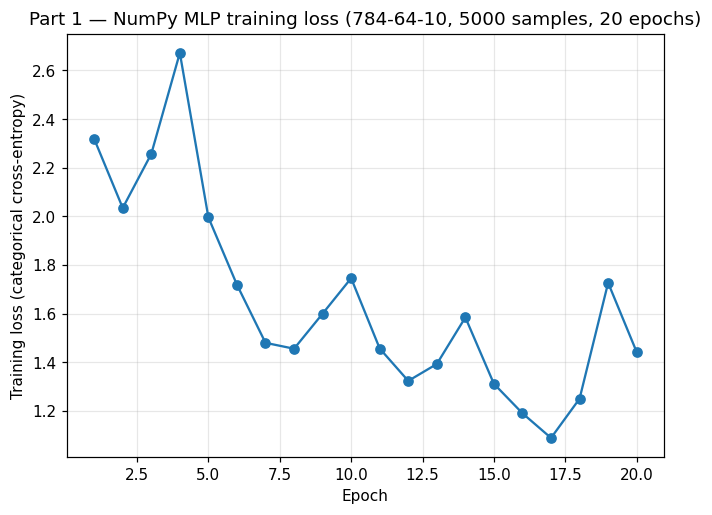

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS_NUMPY + 1), loss_history_np, marker="o")
plt.xlabel("Epoch"); plt.ylabel("Training loss (categorical cross-entropy)")
plt.title("Part 1 — NumPy MLP training loss (784-64-10, 5000 samples, 20 epochs)")
plt.grid(alpha=0.3)
plt.savefig("fig_part1_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## PyTorch Gradient Verification



In [11]:
class MLPTorch(nn.Module):
    def __init__(self, n_in=784, n_hidden=64, n_out=10):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)       
        return x


set_seed(SEED)
model_torch = MLPTorch(784, 64, 10).to(DEVICE)

model_np_check = MLPNumpy(784, 64, 10, seed=SEED)
with torch.no_grad():
    model_torch.fc1.weight.copy_(torch.tensor(model_np_check.W1.T, dtype=torch.float32))
    model_torch.fc1.bias.copy_(torch.tensor(model_np_check.b1.flatten(), dtype=torch.float32))
    model_torch.fc2.weight.copy_(torch.tensor(model_np_check.W2.T, dtype=torch.float32))
    model_torch.fc2.bias.copy_(torch.tensor(model_np_check.b2.flatten(), dtype=torch.float32))

X_batch = X_sub[:64]
y_batch = y_sub[:64]
y_batch_onehot = np.eye(10)[y_batch]

probs_np, cache_np = model_np_check.forward(X_batch)
grads_np = model_np_check.backward(cache_np, y_batch_onehot)

xb_t = torch.tensor(X_batch, dtype=torch.float32, device=DEVICE)
yb_t = torch.tensor(y_batch, dtype=torch.long, device=DEVICE)
model_torch.zero_grad()
logits = model_torch(xb_t)
loss_t = F.cross_entropy(logits, yb_t)
loss_t.backward()

grads_torch = {
    "W1": model_torch.fc1.weight.grad.detach().cpu().numpy().T,   # transpose back to (in, out)
    "b1": model_torch.fc1.bias.grad.detach().cpu().numpy().reshape(1, -1),
    "W2": model_torch.fc2.weight.grad.detach().cpu().numpy().T,
    "b2": model_torch.fc2.bias.grad.detach().cpu().numpy().reshape(1, -1),
}

print(f"NumPy loss on batch   = {model_np_check.cce_loss(probs_np, y_batch_onehot):.6f}")
print(f"PyTorch loss on batch = {loss_t.item():.6f}")
print()
print("Maximum absolute difference between NumPy and PyTorch gradients, per weight matrix:")
max_diffs = {}
for name in ["W1", "b1", "W2", "b2"]:
    diff = np.max(np.abs(grads_np[name] - grads_torch[name]))
    max_diffs[name] = diff
    print(f"  {name}: max abs diff = {diff:.3e}")


NumPy loss on batch   = 2.271077
PyTorch loss on batch = 2.271077

Maximum absolute difference between NumPy and PyTorch gradients, per weight matrix:
  W1: max abs diff = 6.031e-09
  b1: max abs diff = 6.557e-09
  W2: max abs diff = 1.595e-08
  b2: max abs diff = 7.993e-09


# Part 2 - Activation Study




## Model Definition

In [15]:
HIDDEN_SIZES = [256, 128]    
BATCH_SIZE_P2 = 128
EPOCHS_P2 = 15
LR_P2 = 1e-3

ACTIVATIONS = {
    "sigmoid": nn.Sigmoid,
    "tanh": nn.Tanh,
    "relu": nn.ReLU,
    "leaky_relu": lambda: nn.LeakyReLU(0.01),
}

class BaselineMLP(nn.Module):
    """784 -> 256 -> 128 -> 10, with a swappable activation. Same architecture, optimizer,
    learning rate, epochs, batch size, initialisation and data split are used for every
    activation so the comparison isolates the activation function alone."""
    def __init__(self, activation_cls, n_in=784, hidden_sizes=HIDDEN_SIZES, n_out=10, seed=SEED):
        super().__init__()
        torch.manual_seed(seed)   
        layers = []
        sizes = [n_in] + hidden_sizes
        for i in range(len(hidden_sizes)):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            layers.append(activation_cls())
        layers.append(nn.Linear(sizes[-1], n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

print(BaselineMLP(nn.ReLU))


BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Experiments

In [16]:
set_seed(SEED)
train_loader_p2, val_loader_p2 = make_loaders(X_train, y_train, X_val, y_val, batch_size=BATCH_SIZE_P2)

results_p2 = {}
for act_name, act_cls in ACTIVATIONS.items():
    print(f"\n=== Training with activation: {act_name} ===")
    set_seed(SEED)
    model = BaselineMLP(act_cls, seed=SEED)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_P2)
    criterion = nn.CrossEntropyLoss()
    history = train_model(model, train_loader_p2, val_loader_p2, optimizer, criterion,
                           epochs=EPOCHS_P2, track_first_layer_grad=True,
                           first_layer_param_name="net.0.weight", verbose=False)
    results_p2[act_name] = history
    print(f"  final val_loss={history['val_loss'][-1]:.4f}  final val_acc={history['val_acc'][-1]:.4f}")



=== Training with activation: sigmoid ===
  final val_loss=0.3176  final val_acc=0.8847

=== Training with activation: tanh ===
  final val_loss=0.3334  final val_acc=0.8790

=== Training with activation: relu ===
  final val_loss=0.3200  final val_acc=0.8884

=== Training with activation: leaky_relu ===
  final val_loss=0.3130  final val_acc=0.8933


## Validation Curves

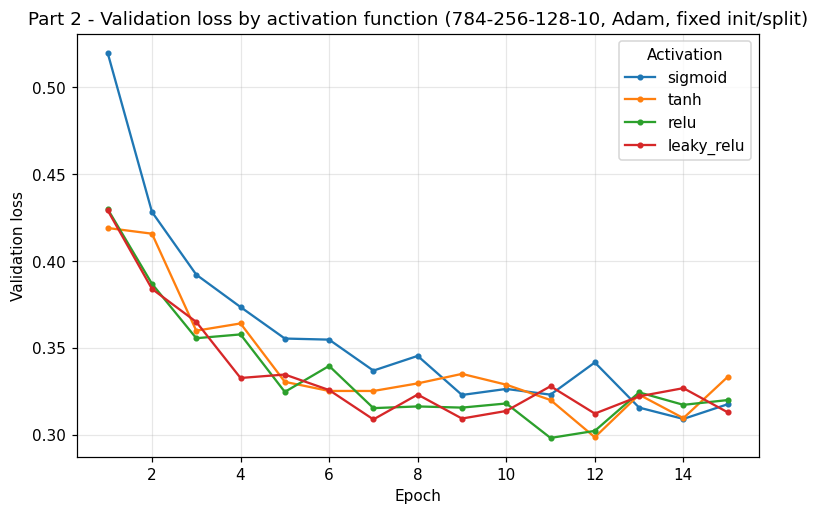

In [17]:
plt.figure(figsize=(8, 5))
for act_name, history in results_p2.items():
    plt.plot(range(1, EPOCHS_P2 + 1), history["val_loss"], marker="o", markersize=3, label=act_name)
plt.xlabel("Epoch"); plt.ylabel("Validation loss")
plt.title("Part 2 - Validation loss by activation function (784-256-128-10, Adam, fixed init/split)")
plt.legend(title="Activation")
plt.grid(alpha=0.3)
plt.savefig("fig_part2_val_loss.png", dpi=150, bbox_inches="tight")
plt.show()


## Gradient Analysis

In [18]:
grad_table = pd.DataFrame({
    "sigmoid_epoch1": [results_p2["sigmoid"]["first_layer_mean_abs_grad"][0]],
    "sigmoid_final": [results_p2["sigmoid"]["first_layer_mean_abs_grad"][-1]],
    "relu_epoch1": [results_p2["relu"]["first_layer_mean_abs_grad"][0]],
    "relu_final": [results_p2["relu"]["first_layer_mean_abs_grad"][-1]],
}, index=["mean abs gradient, first hidden layer"])
grad_table


,sigmoid_epoch1,sigmoid_final,relu_epoch1,relu_final
"mean abs gradient, first hidden layer",9.3422e-05,0.0003,0.0006,0.0006


## Dead ReLU Analysis

In [19]:
set_seed(SEED)
relu_model = BaselineMLP(nn.ReLU, seed=SEED)
optimizer = torch.optim.Adam(relu_model.parameters(), lr=LR_P2)
_ = train_model(relu_model, train_loader_p2, val_loader_p2, optimizer, nn.CrossEntropyLoss(),
                 epochs=EPOCHS_P2, verbose=False)

relu_model.eval()
xb_val, yb_val = next(iter(val_loader_p2))
xb_val = xb_val.to(DEVICE)
with torch.no_grad():
    a1 = relu_model.net[1](relu_model.net[0](xb_val))
    dead_mask = (a1 == 0).all(dim=0)                   
    pct_dead = dead_mask.float().mean().item() * 100

print(f"Validation batch size used: {xb_val.shape[0]}")
print(f"Percentage of first-hidden-layer units that output zero for EVERY sample: {pct_dead:.2f}%")


Validation batch size used: 512
Percentage of first-hidden-layer units that output zero for EVERY sample: 9.38%


# Part 3 - Loss Functions



## Cross Entropy

In [20]:
HIDDEN_SIZES_P3 = HIDDEN_SIZES   
EPOCHS_P3 = 15

set_seed(SEED)
train_loader_p3, val_loader_p3 = make_loaders(X_train, y_train, X_val, y_val, batch_size=BATCH_SIZE_P2)
test_loader_p3 = DataLoader(ArrayDataset(X_test, y_test), batch_size=512, shuffle=False)

model_ce = BaselineMLP(nn.ReLU, seed=SEED)
optimizer_ce = torch.optim.Adam(model_ce.parameters(), lr=LR_P2)
history_ce = train_model(model_ce, train_loader_p3, val_loader_p3, optimizer_ce,
                          nn.CrossEntropyLoss(), epochs=EPOCHS_P3, verbose=False)

test_loss_ce, test_acc_ce = evaluate(model_ce, test_loader_p3, nn.CrossEntropyLoss())
print(f"[Cross-entropy] test accuracy = {test_acc_ce:.4f}")


[Cross-entropy] test accuracy = 0.8904


## MSE Classification

In [21]:
class MSELossOnLogits(nn.Module):
    """MSE between softmax probabilities and one-hot targets (so both losses train through a
    softmax output, keeping the comparison about the loss function, not the output layer)."""
    def forward(self, logits, y_onehot):
        probs = F.softmax(logits, dim=1)
        return F.mse_loss(probs, y_onehot)

set_seed(SEED)
model_mse = BaselineMLP(nn.ReLU, seed=SEED)
optimizer_mse = torch.optim.Adam(model_mse.parameters(), lr=LR_P2)
history_mse = train_model(model_mse, train_loader_p3, val_loader_p3, optimizer_mse,
                           MSELossOnLogits(), epochs=EPOCHS_P3, targets_are_onehot=True,
                           verbose=False)

test_loss_mse, test_acc_mse = evaluate(model_mse, test_loader_p3, MSELossOnLogits(),
                                        targets_are_onehot=True)
print(f"[MSE]            test accuracy = {test_acc_mse:.4f}")
print(f"\nComparison -> CCE test accuracy: {test_acc_ce:.4f} | MSE test accuracy: {test_acc_mse:.4f}")


[MSE]            test accuracy = 0.8906

Comparison -> CCE test accuracy: 0.8904 | MSE test accuracy: 0.8906


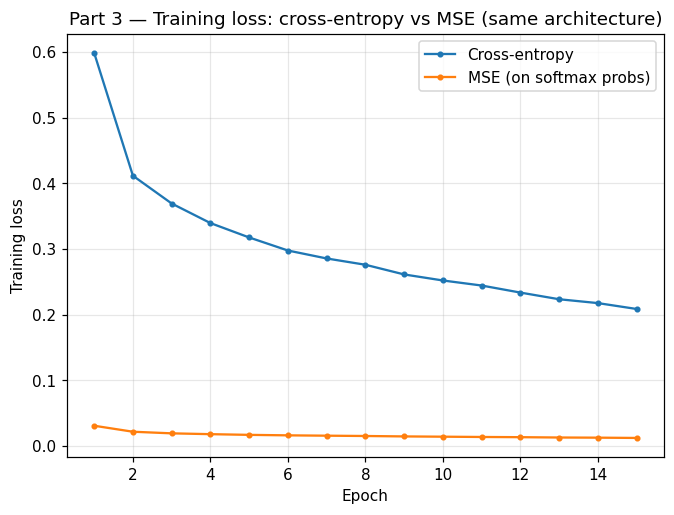

In [22]:
plot_curves([history_ce["train_loss"], history_mse["train_loss"]],
            xlabel="Epoch", ylabel="Training loss",
            title="Part 3 — Training loss: cross-entropy vs MSE (same architecture)",
            legend_labels=["Cross-entropy", "MSE (on softmax probs)"],
            savepath="fig_part3_ce_vs_mse.png")


## Regression Experiment


In [23]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_house, y_house = housing.data, housing.target
print("California Housing:", X_house.shape, "target range:", y_house.min(), "-", y_house.max())

X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(
    X_house, y_house, test_size=0.2, random_state=SEED
)
X_house_train, X_house_val, y_house_train, y_house_val = train_test_split(
    X_house_train, y_house_train, test_size=0.2, random_state=SEED
)

scaler_x = StandardScaler().fit(X_house_train)
scaler_y = StandardScaler().fit(y_house_train.reshape(-1, 1))
def scale(X, y=None):
    Xs = scaler_x.transform(X).astype(np.float32)
    if y is None:
        return Xs
    ys = scaler_y.transform(y.reshape(-1, 1)).astype(np.float32).flatten()
    return Xs, ys

Xh_tr, yh_tr = scale(X_house_train, y_house_train)
Xh_va, yh_va = scale(X_house_val, y_house_val)
Xh_te, yh_te = scale(X_house_test, y_house_test)

class RegressionMLP(nn.Module):
    def __init__(self, n_in=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def make_reg_loader(X, y, batch_size=128, shuffle=True):
    ds = torch.utils.data.TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

reg_train_loader = make_reg_loader(Xh_tr, yh_tr)
reg_val_loader = make_reg_loader(Xh_va, yh_va, shuffle=False)

set_seed(SEED)
reg_model = RegressionMLP(n_in=Xh_tr.shape[1]).to(DEVICE)
reg_optimizer = torch.optim.Adam(reg_model.parameters(), lr=1e-3)
reg_criterion = nn.MSELoss()

EPOCHS_REG = 60
for epoch in range(1, EPOCHS_REG + 1):
    reg_model.train()
    for xb, yb in reg_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        reg_optimizer.zero_grad()
        pred = reg_model(xb)
        loss = reg_criterion(pred, yb)
        loss.backward()
        reg_optimizer.step()
    if epoch % 10 == 0 or epoch == 1:
        reg_model.eval()
        with torch.no_grad():
            val_pred = reg_model(torch.tensor(Xh_va, device=DEVICE))
            val_mse = F.mse_loss(val_pred, torch.tensor(yh_va, device=DEVICE)).item()
        print(f"epoch {epoch:3d}/{EPOCHS_REG} | val MSE (scaled target) = {val_mse:.4f}")

reg_model.eval()
with torch.no_grad():
    test_pred_scaled = reg_model(torch.tensor(Xh_te, device=DEVICE)).cpu().numpy()
test_pred = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()

mse_val = mean_squared_error(y_house_test, test_pred)
rmse_val = math.sqrt(mse_val)
mae_val = mean_absolute_error(y_house_test, test_pred)
print(f"\nRegression test-set metrics (target units: $100,000s, per California Housing docs):")
print(f"  MSE  = {mse_val:.4f}")
print(f"  RMSE = {rmse_val:.4f}")
print(f"  MAE  = {mae_val:.4f}")


California Housing: (20640, 8) target range: 0.14999 - 5.00001
epoch   1/60 | val MSE (scaled target) = 0.4081
epoch  10/60 | val MSE (scaled target) = 0.2699
epoch  20/60 | val MSE (scaled target) = 0.2519
epoch  30/60 | val MSE (scaled target) = 0.2309
epoch  40/60 | val MSE (scaled target) = 0.2242
epoch  50/60 | val MSE (scaled target) = 0.2282
epoch  60/60 | val MSE (scaled target) = 0.2264

Regression test-set metrics (target units: $100,000s, per California Housing docs):
  MSE  = 0.2853
  RMSE = 0.5341
  MAE  = 0.3588


# Part 4 - Optimizer Comparison




## Same Learning Rate

In [24]:
EPOCHS_P4 = 20
BATCH_SIZE_P4 = 128
SAME_LR = 0.01

def make_optimizer(name, params, lr):
    if name == "SGD":
        return torch.optim.SGD(params, lr=lr)
    if name == "SGD + momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if name == "RMSProp":
        return torch.optim.RMSprop(params, lr=lr)
    if name == "Adam":
        return torch.optim.Adam(params, lr=lr)
    raise ValueError(name)

OPTIMIZER_NAMES = ["SGD", "SGD + momentum", "RMSProp", "Adam"]

def run_optimizer_experiment(lr_dict):
    """lr_dict: {optimizer_name: learning_rate}. Returns dict of name -> (history, wall_time)."""
    set_seed(SEED)
    train_loader_p4, val_loader_p4 = make_loaders(X_train, y_train, X_val, y_val,
                                                    batch_size=BATCH_SIZE_P4)
    results = {}
    for name in OPTIMIZER_NAMES:
        set_seed(SEED)
        model = BaselineMLP(nn.ReLU, seed=SEED)
        optimizer = make_optimizer(name, model.parameters(), lr_dict[name])
        t0 = time.perf_counter()
        history = train_model(model, train_loader_p4, val_loader_p4, optimizer,
                               nn.CrossEntropyLoss(), epochs=EPOCHS_P4, verbose=False)
        wall_time = time.perf_counter() - t0
        results[name] = (history, wall_time)
        print(f"{name:16s} lr={lr_dict[name]:<7g} final_val_acc={history['val_acc'][-1]:.4f} "
              f"time={wall_time:.1f}s")
    return results

print("=== Same learning rate for all four optimisers ===")
same_lr_dict = {name: SAME_LR for name in OPTIMIZER_NAMES}
results_same_lr = run_optimizer_experiment(same_lr_dict)


=== Same learning rate for all four optimisers ===
SGD              lr=0.01    final_val_acc=0.8412 time=23.9s
SGD + momentum   lr=0.01    final_val_acc=0.8808 time=24.2s
RMSProp          lr=0.01    final_val_acc=0.8615 time=25.8s
Adam             lr=0.01    final_val_acc=0.8752 time=26.9s


## Tuned Learning Rates

In [25]:
TUNED_LR = {
    "SGD": 0.1,
    "SGD + momentum": 0.05,
    "RMSProp": 0.001,
    "Adam": 0.001,
}

print("=== Learning rate tuned per optimiser ===")
results_tuned_lr = run_optimizer_experiment(TUNED_LR)

=== Learning rate tuned per optimiser ===
SGD              lr=0.1     final_val_acc=0.8878 time=24.0s
SGD + momentum   lr=0.05    final_val_acc=0.8866 time=24.3s
RMSProp          lr=0.001   final_val_acc=0.8935 time=25.6s
Adam             lr=0.001   final_val_acc=0.8925 time=26.2s


## Results Table

In [26]:
def build_optimizer_table(results, lr_dict):
    rows = []
    for name in OPTIMIZER_NAMES:
        history, wall_time = results[name]
        ep85 = epochs_to_reach(history["val_acc"], threshold=0.85)
        rows.append({
            "Optimiser": name,
            "Learning rate": lr_dict[name],
            "Epochs to reach 85% validation accuracy": ep85 if ep85 is not None else "not reached",
            "Final validation accuracy": round(history["val_acc"][-1], 4),
            "Wall-clock time (s)": round(wall_time, 1),
        })
    return pd.DataFrame(rows)

print("Table — same learning rate for all optimisers:")
table_same_lr = build_optimizer_table(results_same_lr, same_lr_dict)
display(table_same_lr)

print("\nTable — learning rate tuned per optimiser (this is the required Part 4 table):")
table_tuned_lr = build_optimizer_table(results_tuned_lr, TUNED_LR)
display(table_tuned_lr)


Table — same learning rate for all optimisers:


,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time (s)
0,SGD,0.01,not reached,0.8412,23.9
1,SGD + momentum,0.01,4,0.8808,24.2
2,RMSProp,0.01,12,0.8615,25.8
3,Adam,0.01,3,0.8752,26.9



Table — learning rate tuned per optimiser (this is the required Part 4 table):


,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time (s)
0,SGD,0.100,6,0.8878,24.0
1,SGD + momentum,0.050,2,0.8866,24.3
2,RMSProp,0.001,2,0.8935,25.6
3,Adam,0.001,2,0.8925,26.2


## Loss Curves

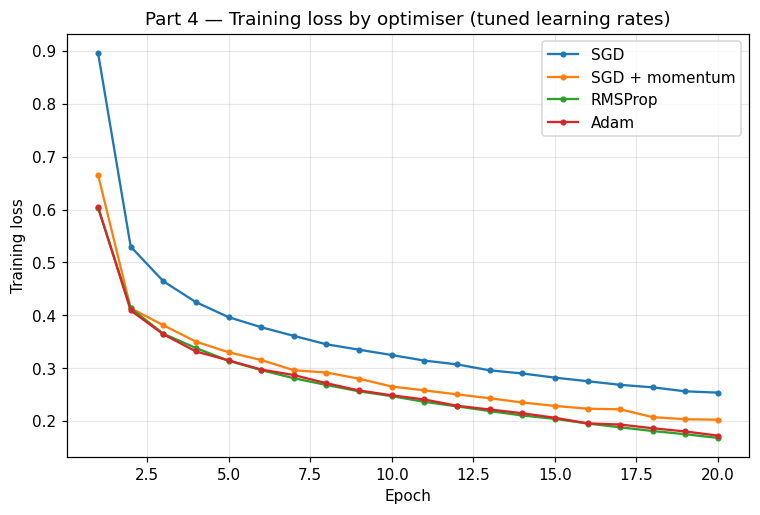

In [27]:
plt.figure(figsize=(8, 5))
for name in OPTIMIZER_NAMES:
    history, _ = results_tuned_lr[name]
    plt.plot(range(1, EPOCHS_P4 + 1), history["train_loss"], marker="o", markersize=3, label=name)
plt.xlabel("Epoch"); plt.ylabel("Training loss")
plt.title("Part 4 — Training loss by optimiser (tuned learning rates)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("fig_part4_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()


# Part 5 - Forced Overfitting



## Large Model

In [28]:
N_OVERFIT = 2000
HIDDEN_SIZES_OVERFIT = [512, 512, 512, 512]   
EPOCHS_OVERFIT = 150
LR_OVERFIT = 1e-3
BATCH_SIZE_OVERFIT = 64

class OverfitMLP(nn.Module):
    def __init__(self, n_in=784, hidden_sizes=HIDDEN_SIZES_OVERFIT, n_out=10, seed=SEED,
                 dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        torch.manual_seed(seed)
        layers = []
        sizes = [n_in] + hidden_sizes
        for i in range(len(hidden_sizes)):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(sizes[i + 1]))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
        layers.append(nn.Linear(sizes[-1], n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

n_params = sum(p.numel() for p in OverfitMLP().parameters())
print(f"OverfitMLP parameter count: {n_params:,} trained on only {N_OVERFIT} samples "
      f"({n_params / N_OVERFIT:.1f} parameters per training example)")


OverfitMLP parameter count: 1,195,018 trained on only 2000 samples (597.5 parameters per training example)


## Training

In [29]:
set_seed(SEED)
idx_overfit = np.random.default_rng(SEED).choice(len(X_train), size=N_OVERFIT, replace=False)
X_overfit = X_train[idx_overfit]
y_overfit = y_train[idx_overfit]

train_loader_p5, val_loader_p5 = make_loaders(X_overfit, y_overfit, X_val, y_val,
                                                batch_size=BATCH_SIZE_OVERFIT)

def train_overfit_model(model, epochs=EPOCHS_OVERFIT, lr=LR_OVERFIT, weight_decay=0.0,
                         verbose_every=25):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = train_model(model, train_loader_p5, val_loader_p5, optimizer,
                           nn.CrossEntropyLoss(), epochs=epochs, verbose=False)
    for i in range(0, epochs, verbose_every):
        print(f"  epoch {i+1:3d} | train_acc={history['train_acc'][i]:.4f} "
              f"val_acc={history['val_acc'][i]:.4f}")
    print(f"  epoch {epochs:3d} | train_acc={history['train_acc'][-1]:.4f} "
          f"val_acc={history['val_acc'][-1]:.4f}  (final)")
    return history

set_seed(SEED)
overfit_model = OverfitMLP(seed=SEED)
history_overfit = train_overfit_model(overfit_model)

final_train_acc = history_overfit["train_acc"][-1]
print(f"\nFinal training accuracy: {final_train_acc:.4f} "
      f"{'(>99% target reached)' if final_train_acc > 0.99 else '(target NOT reached -- increase EPOCHS_OVERFIT)'}")


  epoch   1 | train_acc=0.4300 val_acc=0.5815
  epoch  26 | train_acc=0.9385 val_acc=0.8116
  epoch  51 | train_acc=0.9785 val_acc=0.8218
  epoch  76 | train_acc=0.9900 val_acc=0.8243
  epoch 101 | train_acc=0.9945 val_acc=0.8247
  epoch 126 | train_acc=1.0000 val_acc=0.8344
  epoch 150 | train_acc=1.0000 val_acc=0.8343  (final)

Final training accuracy: 1.0000 (>99% target reached)


## Generalization Gap

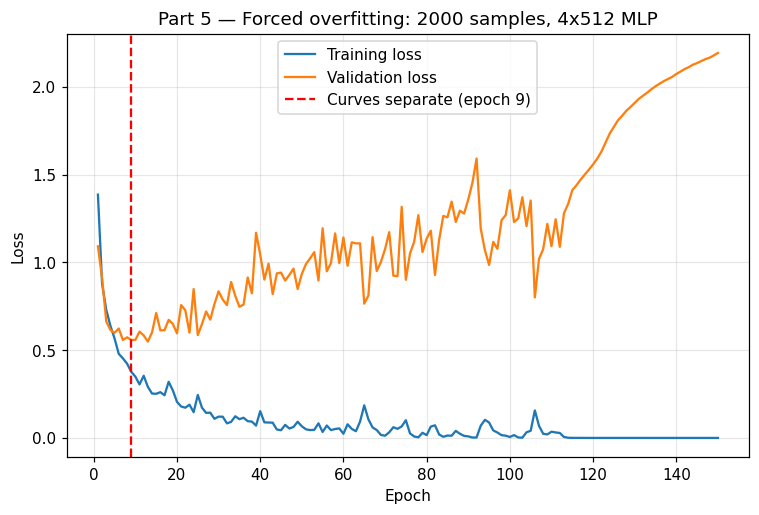

Epoch where curves begin separating: 9
Final training accuracy  : 1.0000
Final validation accuracy: 0.8343
Generalisation gap (train acc - val acc): 0.1657


In [30]:
def find_separation_epoch(train_loss, val_loss, patience=3, rel_gap_threshold=0.02):
    """First epoch where val_loss starts rising while train_loss keeps falling, sustained for
    `patience` consecutive epochs -- a simple, inspectable definition of "where the curves begin
    separating"."""
    for i in range(1, len(val_loss) - patience):
        window_val = val_loss[i:i + patience]
        window_train = train_loss[i:i + patience]
        val_rising = all(window_val[j + 1] > window_val[j] for j in range(len(window_val) - 1))
        train_falling_or_flat = all(window_train[j + 1] <= window_train[j] + 1e-4
                                     for j in range(len(window_train) - 1))
        if val_rising and train_falling_or_flat:
            return i + 1
    return None

sep_epoch = find_separation_epoch(history_overfit["train_loss"], history_overfit["val_loss"])

plt.figure(figsize=(8, 5))
epochs_axis = range(1, EPOCHS_OVERFIT + 1)
plt.plot(epochs_axis, history_overfit["train_loss"], label="Training loss")
plt.plot(epochs_axis, history_overfit["val_loss"], label="Validation loss")
if sep_epoch is not None:
    plt.axvline(sep_epoch, color="red", linestyle="--", label=f"Curves separate (epoch {sep_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title(f"Part 5 — Forced overfitting: {N_OVERFIT} samples, {len(HIDDEN_SIZES_OVERFIT)}x512 MLP")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("fig_part5_overfitting.png", dpi=150, bbox_inches="tight")
plt.show()

final_val_acc = history_overfit["val_acc"][-1]
gen_gap = final_train_acc - final_val_acc
print(f"Epoch where curves begin separating: {sep_epoch}")
print(f"Final training accuracy  : {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")
print(f"Generalisation gap (train acc - val acc): {gen_gap:.4f}")


## Bias/Variance Diagnosis


# Part 6 — Regularization Study




In [32]:
regularization_results = {}   

def record_result(label, setting, train_acc, val_acc, extra=None):
    regularization_results[label] = {
        "Method": label.split(" (")[0],
        "Setting": setting,
        "Train accuracy": round(train_acc, 4),
        "Validation accuracy": round(val_acc, 4),
        "Gap": round(train_acc - val_acc, 4),
    }
    if extra:
        regularization_results[label].update(extra)
record_result("Baseline (no regularisation)", "-", final_train_acc, final_val_acc)
print(regularization_results["Baseline (no regularisation)"])


{'Method': 'Baseline', 'Setting': '-', 'Train accuracy': 1.0, 'Validation accuracy': 0.8343, 'Gap': 0.1657}


## L2

In [33]:
L2_LAMBDAS = [1e-4, 1e-3, 1e-2]

for lam in L2_LAMBDAS:
    set_seed(SEED)
    model = OverfitMLP(seed=SEED)
    hist = train_overfit_model(model, weight_decay=lam, verbose_every=50)
    record_result(f"L2 weight decay (lambda={lam:g})", f"lambda={lam:g}",
                  hist["train_acc"][-1], hist["val_acc"][-1])
    print(f"lambda={lam:g}: {regularization_results[f'L2 weight decay (lambda={lam:g})']}\n")


  epoch   1 | train_acc=0.4590 val_acc=0.5923
  epoch  51 | train_acc=0.9885 val_acc=0.8251
  epoch 101 | train_acc=1.0000 val_acc=0.8343
  epoch 150 | train_acc=0.9950 val_acc=0.8274  (final)
lambda=0.0001: {'Method': 'L2 weight decay', 'Setting': 'lambda=0.0001', 'Train accuracy': 0.995, 'Validation accuracy': 0.8274, 'Gap': 0.1676}

  epoch   1 | train_acc=0.4245 val_acc=0.5344
  epoch  51 | train_acc=0.9665 val_acc=0.8216
  epoch 101 | train_acc=0.9995 val_acc=0.8156
  epoch 150 | train_acc=0.9940 val_acc=0.8257  (final)
lambda=0.001: {'Method': 'L2 weight decay', 'Setting': 'lambda=0.001', 'Train accuracy': 0.994, 'Validation accuracy': 0.8257, 'Gap': 0.1683}

  epoch   1 | train_acc=0.2975 val_acc=0.4403
  epoch  51 | train_acc=0.9090 val_acc=0.8111
  epoch 101 | train_acc=0.9560 val_acc=0.7828
  epoch 150 | train_acc=0.9470 val_acc=0.8120  (final)
lambda=0.01: {'Method': 'L2 weight decay', 'Setting': 'lambda=0.01', 'Train accuracy': 0.947, 'Validation accuracy': 0.812, 'Gap': 0.

## L1

In [34]:
L1_LAMBDA = 1e-4

def train_with_l1(model, l1_lambda, epochs=EPOCHS_OVERFIT, lr=LR_OVERFIT):
    model.to(DEVICE)   
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = defaultdict(list)
    linear_weights = [p for n, p in model.named_parameters() if n.endswith(".weight") and p.dim() == 2]
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, n = 0.0, 0, 0
        for xb, yb in train_loader_p5:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            l1_term = sum(w.abs().sum() for w in linear_weights)
            loss = criterion(out, yb) + l1_lambda * l1_term
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            n += xb.size(0)
        train_loss, train_acc = running_loss / n, correct / n
        val_loss, val_acc = evaluate(model, val_loader_p5, criterion)
        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    return dict(history)

set_seed(SEED)
l1_model = OverfitMLP(seed=SEED)
hist_l1 = train_with_l1(l1_model, L1_LAMBDA)
record_result("L1 penalty", f"lambda={L1_LAMBDA:g}", hist_l1["train_acc"][-1], hist_l1["val_acc"][-1])

with torch.no_grad():
    all_weights = torch.cat([p.flatten() for n, p in l1_model.named_parameters()
                              if n.endswith(".weight") and p.dim() == 2])
    pct_below = (all_weights.abs() < 1e-3).float().mean().item() * 100

print(f"L1 (lambda={L1_LAMBDA:g}): train_acc={hist_l1['train_acc'][-1]:.4f} "
      f"val_acc={hist_l1['val_acc'][-1]:.4f}")
print(f"Percentage of weights with |w| < 1e-3 after L1 training: {pct_below:.2f}%")


L1 (lambda=0.0001): train_acc=1.0000 val_acc=0.8224
Percentage of weights with |w| < 1e-3 after L1 training: 97.57%


## Dropout

In [35]:
DROPOUT_RATES = [0.2, 0.4, 0.6]

for rate in DROPOUT_RATES:
    set_seed(SEED)
    model = OverfitMLP(seed=SEED, dropout_rate=rate)
    hist = train_overfit_model(model, verbose_every=50)
    record_result(f"Dropout (p={rate})", f"p={rate}", hist["train_acc"][-1], hist["val_acc"][-1])
    print(f"dropout p={rate}: {regularization_results[f'Dropout (p={rate})']}\n")


  epoch   1 | train_acc=0.4080 val_acc=0.6320
  epoch  51 | train_acc=0.9355 val_acc=0.8264
  epoch 101 | train_acc=0.9745 val_acc=0.8313
  epoch 150 | train_acc=0.9830 val_acc=0.8383  (final)
dropout p=0.2: {'Method': 'Dropout', 'Setting': 'p=0.2', 'Train accuracy': 0.983, 'Validation accuracy': 0.8383, 'Gap': 0.1447}

  epoch   1 | train_acc=0.3080 val_acc=0.5201
  epoch  51 | train_acc=0.9045 val_acc=0.8336
  epoch 101 | train_acc=0.9300 val_acc=0.8275
  epoch 150 | train_acc=0.9655 val_acc=0.8372  (final)
dropout p=0.4: {'Method': 'Dropout', 'Setting': 'p=0.4', 'Train accuracy': 0.9655, 'Validation accuracy': 0.8372, 'Gap': 0.1283}

  epoch   1 | train_acc=0.1580 val_acc=0.2287
  epoch  51 | train_acc=0.8525 val_acc=0.8253
  epoch 101 | train_acc=0.8895 val_acc=0.8316
  epoch 150 | train_acc=0.9000 val_acc=0.8250  (final)
dropout p=0.6: {'Method': 'Dropout', 'Setting': 'p=0.6', 'Train accuracy': 0.9, 'Validation accuracy': 0.825, 'Gap': 0.075}



## Batch Normalization

In [36]:
set_seed(SEED)
bn_model = OverfitMLP(seed=SEED, use_batchnorm=True)
hist_bn = train_overfit_model(bn_model, verbose_every=50)
record_result("Batch normalisation", "-", hist_bn["train_acc"][-1], hist_bn["val_acc"][-1])
print(regularization_results["Batch normalisation"])


  epoch   1 | train_acc=0.6990 val_acc=0.7678
  epoch  51 | train_acc=0.9940 val_acc=0.8080
  epoch 101 | train_acc=0.9955 val_acc=0.8223
  epoch 150 | train_acc=0.9955 val_acc=0.8057  (final)
{'Method': 'Batch normalisation', 'Setting': '-', 'Train accuracy': 0.9955, 'Validation accuracy': 0.8057, 'Gap': 0.1898}


## Early Stopping

In [37]:
EARLY_STOP_PATIENCE = 10

def train_with_early_stopping(model, patience=EARLY_STOP_PATIENCE, max_epochs=EPOCHS_OVERFIT,
                               lr=LR_OVERFIT):
    model.to(DEVICE)   
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    stopped_epoch = max_epochs
    history = defaultdict(list)
    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss, correct, n = 0.0, 0, 0
        for xb, yb in train_loader_p5:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            n += xb.size(0)
        train_loss, train_acc = running_loss / n, correct / n
        val_loss, val_acc = evaluate(model, val_loader_p5, criterion)
        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                stopped_epoch = epoch
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return dict(history), stopped_epoch

set_seed(SEED)
es_model = OverfitMLP(seed=SEED)
hist_es, stopped_epoch = train_with_early_stopping(es_model)
final_train_acc_es, final_val_acc_es = evaluate(es_model, train_loader_p5, nn.CrossEntropyLoss())[1], \
                                        evaluate(es_model, val_loader_p5, nn.CrossEntropyLoss())[1]
record_result("Early stopping", f"patience={EARLY_STOP_PATIENCE}, stopped at epoch {stopped_epoch}",
              final_train_acc_es, final_val_acc_es)
print(f"Patience = {EARLY_STOP_PATIENCE}. Training stopped at epoch {stopped_epoch} "
      f"(best-val-loss weights restored).")
print(regularization_results["Early stopping"])


Patience = 10. Training stopped at epoch 23 (best-val-loss weights restored).
{'Method': 'Early stopping', 'Setting': 'patience=10, stopped at epoch 23', 'Train accuracy': 0.9125, 'Validation accuracy': 0.823, 'Gap': 0.0895}


## Data Augmentation

{'Method': 'Data augmentation', 'Setting': 'flip(p=0.5) + rotate(+-15 deg)', 'Train accuracy': 0.9635, 'Validation accuracy': 0.8247, 'Gap': 0.1388}


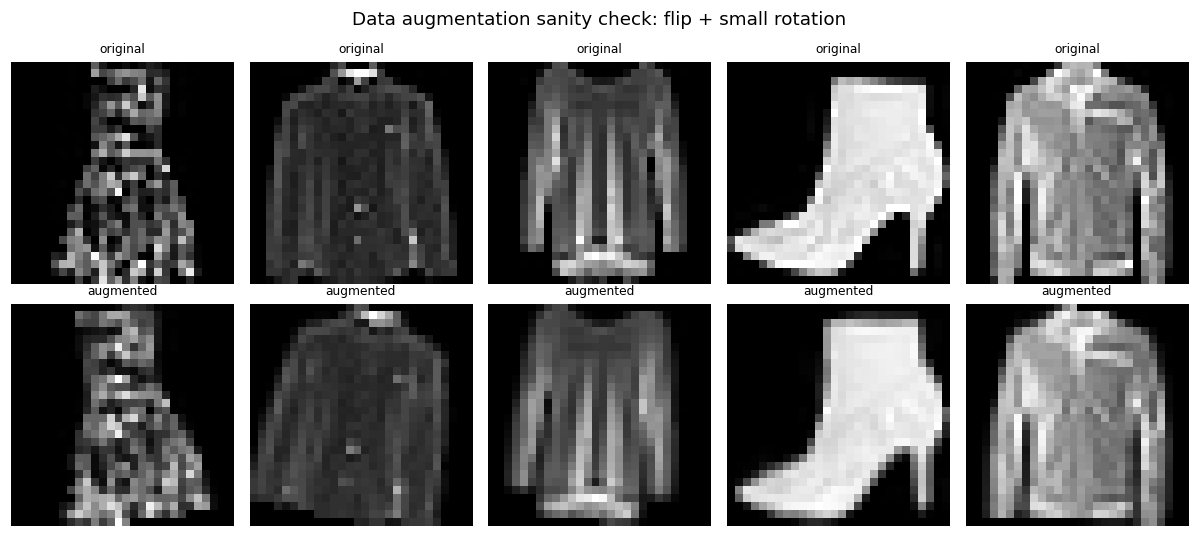

In [38]:
from scipy.ndimage import rotate as ndi_rotate

def augment_flip_rotate(x_flat, rng=None, p_flip=0.5, max_rotation_deg=15):
    """x_flat: (784,) float array in [0,1]. Applies a random horizontal flip and a small random
    rotation, returns a (784,) float array."""
    rng = rng or np.random
    img = x_flat.reshape(28, 28)
    if rng.random() < p_flip:
        img = img[:, ::-1]
    angle = rng.uniform(-max_rotation_deg, max_rotation_deg)
    img = ndi_rotate(img, angle, reshape=False, order=1, mode="constant", cval=0.0)
    return np.clip(img, 0.0, 1.0).reshape(-1).astype(np.float32)

class AugmentTransform:
    def __init__(self, seed=SEED):
        self.rng = np.random.default_rng(seed)
    def __call__(self, x):
        return augment_flip_rotate(x, rng=self.rng)

set_seed(SEED)
aug_transform = AugmentTransform(seed=SEED)
train_loader_aug, val_loader_p5_aug = make_loaders(X_overfit, y_overfit, X_val, y_val,
                                                     batch_size=BATCH_SIZE_OVERFIT,
                                                     transform=aug_transform)

aug_model = OverfitMLP(seed=SEED)
optimizer_aug = torch.optim.Adam(aug_model.parameters(), lr=LR_OVERFIT)
hist_aug = train_model(aug_model, train_loader_aug, val_loader_p5, optimizer_aug,
                        nn.CrossEntropyLoss(), epochs=EPOCHS_OVERFIT, verbose=False)
record_result("Data augmentation", "flip(p=0.5) + rotate(+-15 deg)",
              hist_aug["train_acc"][-1], hist_aug["val_acc"][-1])
print(regularization_results["Data augmentation"])

# Visual sanity check: show a few augmented examples next to their originals.
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
rng_show = np.random.default_rng(SEED)
sample_idx = rng_show.choice(len(X_overfit), 5, replace=False)
for i, idx in enumerate(sample_idx):
    axes[0, i].imshow(X_overfit[idx].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
    axes[0, i].set_title("original", fontsize=8)
    axes[1, i].imshow(augment_flip_rotate(X_overfit[idx], rng=rng_show).reshape(28, 28), cmap="gray")
    axes[1, i].axis("off"); axes[1, i].set_title("augmented", fontsize=8)
fig.suptitle("Data augmentation sanity check: flip + small rotation")
plt.tight_layout()
plt.savefig("fig_part6_augmentation_examples.png", dpi=150)
plt.show()


## More Training Data

In [39]:
for n_samples in [10_000, 20_000]:
    set_seed(SEED)
    idx_more = np.random.default_rng(SEED).choice(len(X_train), size=n_samples, replace=False)
    X_more, y_more = X_train[idx_more], y_train[idx_more]
    train_loader_more, val_loader_more = make_loaders(X_more, y_more, X_val, y_val,
                                                        batch_size=BATCH_SIZE_OVERFIT)
    model = OverfitMLP(seed=SEED)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_OVERFIT)
    hist = train_model(model, train_loader_more, val_loader_more, optimizer,
                        nn.CrossEntropyLoss(), epochs=EPOCHS_OVERFIT, verbose=False)
    record_result(f"More training data ({n_samples} samples)", f"N={n_samples}",
                  hist["train_acc"][-1], hist["val_acc"][-1])
    print(f"N={n_samples}: {regularization_results[f'More training data ({n_samples} samples)']}")


N=10000: {'Method': 'More training data', 'Setting': 'N=10000', 'Train accuracy': 0.9917, 'Validation accuracy': 0.8657, 'Gap': 0.126}
N=20000: {'Method': 'More training data', 'Setting': 'N=20000', 'Train accuracy': 0.993, 'Validation accuracy': 0.8784, 'Gap': 0.1146}


## Combined Results

In [40]:
reg_table = pd.DataFrame(list(regularization_results.values()))
reg_table = reg_table[["Method", "Setting", "Train accuracy", "Validation accuracy", "Gap"]]
reg_table


,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline,-,1.0000,0.8343,0.1657
1,L2 weight decay,lambda=0.0001,0.9950,0.8274,0.1676
2,L2 weight decay,lambda=0.001,0.9940,0.8257,0.1683
3,L2 weight decay,lambda=0.01,0.9470,0.8120,0.1350
4,L1 penalty,lambda=0.0001,1.0000,0.8224,0.1776
5,Dropout,p=0.2,0.9830,0.8383,0.1447
6,Dropout,p=0.4,0.9655,0.8372,0.1283
7,Dropout,p=0.6,0.9000,0.8250,0.0750
8,Batch normalisation,-,0.9955,0.8057,0.1898
9,Early stopping,"patience=10, stopped at epoch 23",0.9125,0.8230,0.0895


## Gap Plots

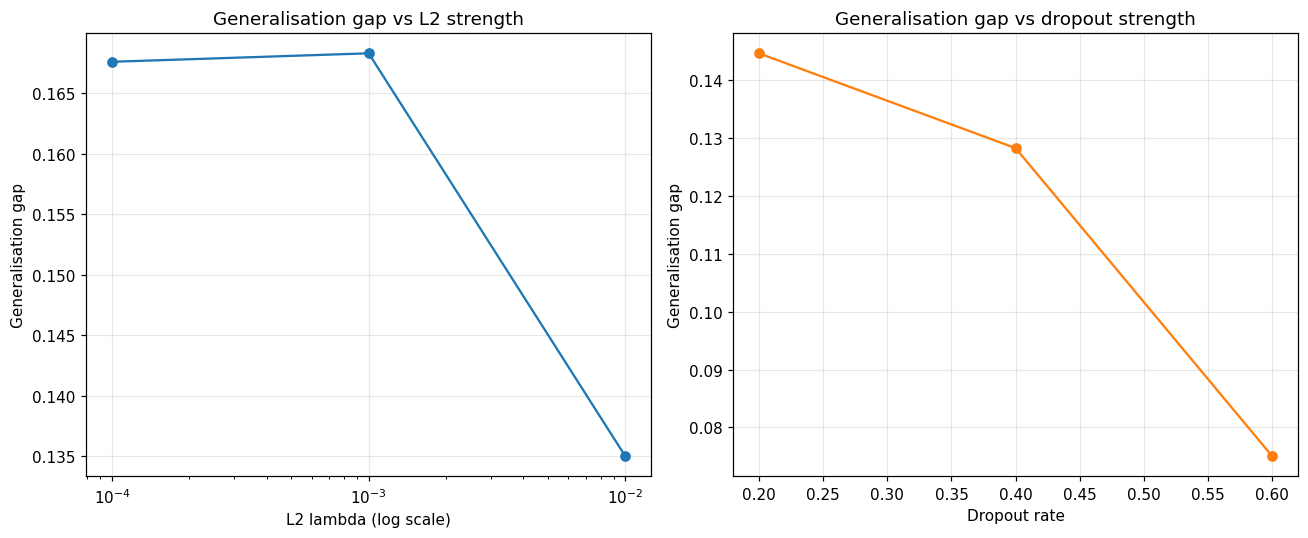

In [41]:
l2_settings = [(lam, regularization_results[f"L2 weight decay (lambda={lam:g})"]["Gap"])
               for lam in L2_LAMBDAS]
dropout_settings = [(p, regularization_results[f"Dropout (p={p})"]["Gap"]) for p in DROPOUT_RATES]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot([s[0] for s in l2_settings], [s[1] for s in l2_settings], marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("L2 lambda (log scale)"); axes[0].set_ylabel("Generalisation gap")
axes[0].set_title("Generalisation gap vs L2 strength")
axes[0].grid(alpha=0.3)

axes[1].plot([s[0] for s in dropout_settings], [s[1] for s in dropout_settings], marker="o", color="tab:orange")
axes[1].set_xlabel("Dropout rate"); axes[1].set_ylabel("Generalisation gap")
axes[1].set_title("Generalisation gap vs dropout strength")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_part6_gap_vs_strength.png", dpi=150, bbox_inches="tight")
plt.show()


# Part 7 — Hyperparameter Search



## Search Space

In [42]:
from scipy.stats import loguniform, uniform

SEARCH_SPACE = {
    "learning_rate": loguniform(1e-4, 1e-2),      # log-uniform: same probability per decade
    "hidden_width": [64, 128, 256, 512],          # width of both hidden layers
    "dropout_rate": uniform(0.0, 0.5),            # uniform in [0.0, 0.5)
}
N_CONFIGS = 12
N_FOLDS = 5
CV_EPOCHS = 8          # kept small deliberately: 12 configs x 5 folds x CV_EPOCHS must fit a T4 session
CV_SUBSET_SIZE = 12_000  # subsample of the 60k training pool used for the search itself, for speed;
                          # the FINAL selected config is retrained on the full 60k afterwards.

print("Search space:")
for k, v in SEARCH_SPACE.items():
    print(f"  {k}: {v}")
print(f"\nNumber of random configurations: {N_CONFIGS}")
print(f"Cross-validation folds: {N_FOLDS}")
print(f"CV epochs per fold: {CV_EPOCHS}")
print(f"CV search subsample size: {CV_SUBSET_SIZE} (drawn from the training pool only)")


Search space:
  learning_rate: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c00a9779100>
  hidden_width: [64, 128, 256, 512]
  dropout_rate: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c00a9922f30>

Number of random configurations: 12
Cross-validation folds: 5
CV epochs per fold: 8
CV search subsample size: 12000 (drawn from the training pool only)


## 5-Fold CV

In [43]:
class TunableMLP(nn.Module):
    def __init__(self, hidden_width, dropout_rate, n_in=784, n_out=10, seed=SEED):
        super().__init__()
        torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden_width), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_width, hidden_width), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_width, n_out),
        )
    def forward(self, x):
        return self.net(x)


def cross_validate_config(config, X, y, n_folds=N_FOLDS, epochs=CV_EPOCHS, seed=SEED):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    fold_val_accs = []
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
        set_seed(seed + fold_idx)
        X_tr_fold, y_tr_fold = X[tr_idx], y[tr_idx]
        X_va_fold, y_va_fold = X[va_idx], y[va_idx]
        loader_tr, loader_va = make_loaders(X_tr_fold, y_tr_fold, X_va_fold, y_va_fold,
                                             batch_size=128, seed=seed + fold_idx)
        model = TunableMLP(config["hidden_width"], config["dropout_rate"], seed=seed)
        optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
        history = train_model(model, loader_tr, loader_va, optimizer, nn.CrossEntropyLoss(),
                               epochs=epochs, verbose=False)
        fold_val_accs.append(history["val_acc"][-1])
    return np.array(fold_val_accs)

print("cross_validate_config() defined -- one call trains 5 models (one per fold) for one config.")


cross_validate_config() defined -- one call trains 5 models (one per fold) for one config.


## Random Search

In [44]:
set_seed(SEED)
rng_search = np.random.default_rng(SEED)

idx_cv_subset = rng_search.choice(len(X_train_full), size=CV_SUBSET_SIZE, replace=False)
X_cv, y_cv = X_train_full[idx_cv_subset], y_train_full[idx_cv_subset]

configs = []
for i in range(N_CONFIGS):
    configs.append({
        "learning_rate": float(SEARCH_SPACE["learning_rate"].rvs(random_state=SEED * 1000 + i)),
        "hidden_width": int(rng_search.choice(SEARCH_SPACE["hidden_width"])),
        "dropout_rate": float(SEARCH_SPACE["dropout_rate"].rvs(random_state=SEED * 1000 + i)),
    })

search_results = []
for i, config in enumerate(configs):
    t0 = time.perf_counter()
    fold_scores = cross_validate_config(config, X_cv, y_cv)
    elapsed = time.perf_counter() - t0
    search_results.append({
        "config_id": i,
        "learning_rate": config["learning_rate"],
        "hidden_width": config["hidden_width"],
        "dropout_rate": config["dropout_rate"],
        "mean_cv_accuracy": fold_scores.mean(),
        "std_cv_accuracy": fold_scores.std(),
        "fold_scores": fold_scores.tolist(),
    })
    print(f"[{i+1:2d}/{N_CONFIGS}] lr={config['learning_rate']:.5f} "
          f"width={config['hidden_width']:3d} dropout={config['dropout_rate']:.3f} "
          f"-> mean CV acc = {fold_scores.mean():.4f} (+/- {fold_scores.std():.4f}) "
          f"[{elapsed:.1f}s]")

search_df = pd.DataFrame(search_results).sort_values("mean_cv_accuracy", ascending=False).reset_index(drop=True)


[ 1/12] lr=0.00017 width=256 dropout=0.059 -> mean CV acc = 0.8271 (+/- 0.0024) [11.0s]
[ 2/12] lr=0.00222 width=128 dropout=0.336 -> mean CV acc = 0.8438 (+/- 0.0063) [11.1s]
[ 3/12] lr=0.00021 width= 64 dropout=0.082 -> mean CV acc = 0.7937 (+/- 0.0039) [11.1s]
[ 4/12] lr=0.00048 width= 64 dropout=0.171 -> mean CV acc = 0.8213 (+/- 0.0035) [10.9s]
[ 5/12] lr=0.00488 width=256 dropout=0.422 -> mean CV acc = 0.8326 (+/- 0.0086) [11.6s]
[ 6/12] lr=0.00733 width=256 dropout=0.466 -> mean CV acc = 0.8238 (+/- 0.0132) [11.4s]
[ 7/12] lr=0.00029 width=256 dropout=0.117 -> mean CV acc = 0.8372 (+/- 0.0064) [11.2s]
[ 8/12] lr=0.00197 width= 64 dropout=0.324 -> mean CV acc = 0.8380 (+/- 0.0027) [11.2s]
[ 9/12] lr=0.00555 width=256 dropout=0.436 -> mean CV acc = 0.8311 (+/- 0.0080) [11.4s]
[10/12] lr=0.00071 width= 64 dropout=0.213 -> mean CV acc = 0.8293 (+/- 0.0048) [11.1s]
[11/12] lr=0.00015 width= 64 dropout=0.042 -> mean CV acc = 0.7791 (+/- 0.0050) [11.1s]
[12/12] lr=0.00411 width=128 dro

## Top 5 Configurations

In [45]:
top5 = search_df.head(5)[["config_id", "learning_rate", "hidden_width", "dropout_rate",
                            "mean_cv_accuracy", "std_cv_accuracy"]]
top5


,config_id,learning_rate,hidden_width,dropout_rate,mean_cv_accuracy,std_cv_accuracy
0,1,0.0022,128,0.3365,0.8438,0.0063
1,7,0.0020,64,0.3239,0.8380,0.0027
2,6,0.0003,256,0.1167,0.8372,0.0064
3,11,0.0041,128,0.4036,0.8368,0.0047
4,4,0.0049,256,0.4222,0.8326,0.0086


In [46]:
selected_config = search_df.iloc[0].to_dict()
print("Selected configuration (highest mean CV accuracy):")
print(f"  learning_rate = {selected_config['learning_rate']:.5f}")
print(f"  hidden_width  = {int(selected_config['hidden_width'])}")
print(f"  dropout_rate  = {selected_config['dropout_rate']:.3f}")
print(f"  mean CV accuracy = {selected_config['mean_cv_accuracy']:.4f} "
      f"(+/- {selected_config['std_cv_accuracy']:.4f})")


Selected configuration (highest mean CV accuracy):
  learning_rate = 0.00222
  hidden_width  = 128
  dropout_rate  = 0.336
  mean CV accuracy = 0.8438 (+/- 0.0063)


## Final Model

In [47]:
print(reg_table.sort_values("Gap"))

BEST_REG_METHOD = "dropout"   
BEST_REG_STRENGTH = 0.4

class FinalModel(nn.Module):
    def __init__(self, hidden_width, dropout_rate, use_batchnorm=False, n_in=784, n_out=10, seed=SEED):
        super().__init__()
        torch.manual_seed(seed)
        layers = [nn.Linear(n_in, hidden_width)]
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden_width))
        layers += [nn.ReLU(), nn.Dropout(dropout_rate),
                   nn.Linear(hidden_width, hidden_width)]
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden_width))
        layers += [nn.ReLU(), nn.Dropout(dropout_rate),
                   nn.Linear(hidden_width, n_out)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

set_seed(SEED)
final_dropout = BEST_REG_STRENGTH if BEST_REG_METHOD == "dropout" else 0.0
final_weight_decay = BEST_REG_STRENGTH if BEST_REG_METHOD == "l2" else 0.0
final_use_bn = (BEST_REG_METHOD == "batchnorm")

final_model = FinalModel(int(selected_config["hidden_width"]), final_dropout,
                          use_batchnorm=final_use_bn, seed=SEED)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=selected_config["learning_rate"],
                                    weight_decay=final_weight_decay)

final_train_loader = DataLoader(ArrayDataset(X_train_full, y_train_full), batch_size=128,
                                 shuffle=True, generator=torch.Generator().manual_seed(SEED))
FINAL_EPOCHS = 20
final_model.to(DEVICE)
for epoch in range(1, FINAL_EPOCHS + 1):
    final_model.train()
    running_loss, correct, n = 0.0, 0, 0
    for xb, yb in final_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        final_optimizer.zero_grad()
        out = final_model(xb)
        loss = nn.functional.cross_entropy(out, yb)
        loss.backward()
        final_optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:2d}/{FINAL_EPOCHS} | train_loss={running_loss/n:.4f} train_acc={correct/n:.4f}")


                 Method                           Setting  Train accuracy  \
7               Dropout                             p=0.6          0.9000   
9        Early stopping  patience=10, stopped at epoch 23          0.9125   
12   More training data                           N=20000          0.9930   
11   More training data                           N=10000          0.9917   
6               Dropout                             p=0.4          0.9655   
3       L2 weight decay                       lambda=0.01          0.9470   
10    Data augmentation    flip(p=0.5) + rotate(+-15 deg)          0.9635   
5               Dropout                             p=0.2          0.9830   
0              Baseline                                 -          1.0000   
1       L2 weight decay                     lambda=0.0001          0.9950   
2       L2 weight decay                      lambda=0.001          0.9940   
4            L1 penalty                     lambda=0.0001          1.0000   

## Held-Out Test Evaluation

In [48]:
final_model.eval()
test_loader_final = DataLoader(ArrayDataset(X_test, y_test), batch_size=512, shuffle=False)
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader_final:
        xb = xb.to(DEVICE)
        preds = final_model(xb).argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())
all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

test_accuracy = accuracy_score(all_true, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_true, all_preds, average="macro")

print(f"Test accuracy   : {test_accuracy:.4f}")
print(f"Macro precision : {precision:.4f}")
print(f"Macro recall    : {recall:.4f}")
print(f"Macro F1        : {f1:.4f}")


Test accuracy   : 0.8809
Macro precision : 0.8816
Macro recall    : 0.8809
Macro F1        : 0.8800


## Confusion Matrix

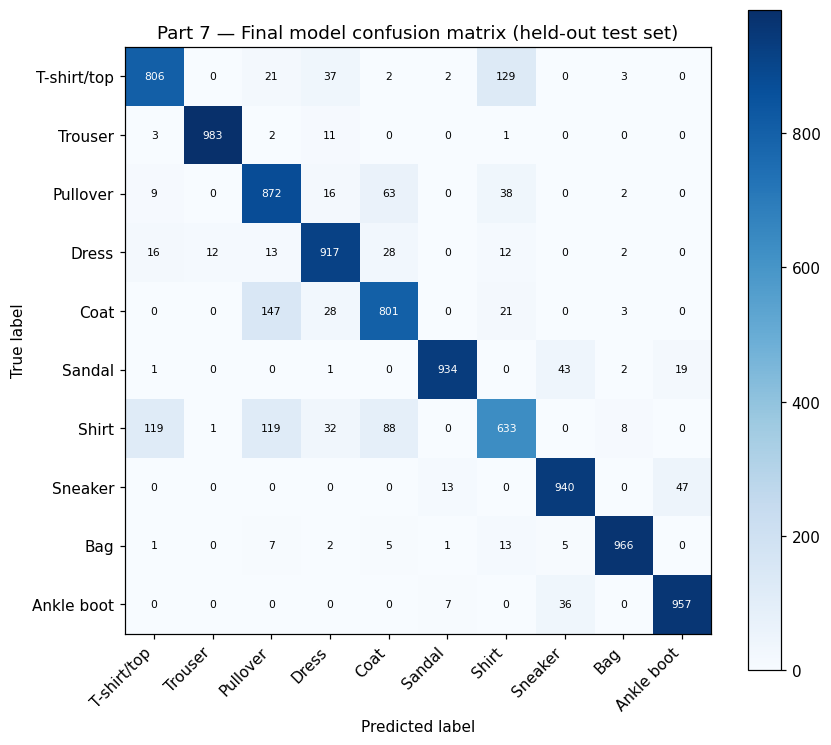

In [49]:
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
ax.set_title("Part 7 — Final model confusion matrix (held-out test set)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
fig.colorbar(im)
plt.tight_layout()
plt.savefig("fig_part7_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
